## 0. Setup, seeds, output folders, DPI config

In [1]:

import os, sys, time, json, random, zipfile, urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, ConfusionMatrixDisplay)

# ---- reproducibility -------------------------------------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ---- output dirs ------------------------------------------------------------
# Works on Kaggle (/kaggle/working) and Colab/local (./) automatically.
BASE_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
FIG_DIR  = os.path.join(BASE_DIR, "figures")
TAB_DIR  = os.path.join(BASE_DIR, "tables")
DATA_DIR = os.path.join(BASE_DIR, "data")
for d in (FIG_DIR, TAB_DIR, DATA_DIR):
    os.makedirs(d, exist_ok=True)

DPI = 300  # every figure in this notebook is saved at 300 dpi

def savefig(fig, name):
    """Save a matplotlib figure to FIG_DIR at 300 dpi and also show it inline."""
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=DPI, bbox_inches="tight")
    print(f"Saved: {path}")
    plt.show()

def savetab(df, name):
    path = os.path.join(TAB_DIR, name)
    df.to_csv(path, index=False)
    print(f"Saved: {path}")
    return df

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))
print("Outputs will be written under:", BASE_DIR)


TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Outputs will be written under: /kaggle/working


In [2]:

# ---- 3. Download & extract the UCI HAR raw-signal dataset -------------------
# Classic mirror used by most tutorials (works when Internet is ON in Kaggle,
# or on Colab by default).
HAR_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
HAR_ZIP = os.path.join(DATA_DIR, "UCI_HAR_Dataset.zip")
HAR_ROOT = os.path.join(DATA_DIR, "UCI HAR Dataset")

if not os.path.isdir(HAR_ROOT):
    try:
        print("Downloading UCI HAR dataset ...")
        urllib.request.urlretrieve(HAR_URL, HAR_ZIP)
        with zipfile.ZipFile(HAR_ZIP, "r") as z:
            z.extractall(DATA_DIR)
        print("Done ->", HAR_ROOT)
    except Exception as e:
        print("Download failed:", e)
        print("Fallback: on Kaggle, click 'Add Data' and search for "
              "'Human Activity Recognition Using Smartphones' / 'UCI HAR', "
              "then point HAR_ROOT at the folder that contains "
              "'train/Inertial Signals' and 'test/Inertial Signals'.")
else:
    print("Dataset already present at", HAR_ROOT)


Done -> /kaggle/working/data/UCI HAR Dataset


In [3]:

# ---- Load the 9 raw inertial-signal channels for a given split --------------
SIGNALS = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]
CLASS_NAMES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
               "SITTING", "STANDING", "LAYING"]

def load_split(root, split):
    sig_dir = os.path.join(root, split, "Inertial Signals")
    channels = []
    for sig in SIGNALS:
        fpath = os.path.join(sig_dir, f"{sig}_{split}.txt")
        arr = np.loadtxt(fpath)                      # (N, 128)
        channels.append(arr)
    X = np.stack(channels, axis=-1)                   # (N, 128, 9)
    y = np.loadtxt(os.path.join(root, split, f"y_{split}.txt")).astype(int) - 1  # 1..6 -> 0..5
    return X, y

X_train_full, y_train_full = load_split(HAR_ROOT, "train")
X_test_full,  y_test_full  = load_split(HAR_ROOT, "test")

print("Raw shapes  -> train:", X_train_full.shape, "test:", X_test_full.shape)


Raw shapes  -> train: (7352, 128, 9) test: (2947, 128, 9)


In [4]:

# ---- Recommended laboratory subset: 1500-3000 windows, class-balanced -------
SUBSET_SIZE = 2400  # within the 1500-3000 range suggested by the handout

X_all = np.concatenate([X_train_full, X_test_full], axis=0)
y_all = np.concatenate([y_train_full, y_test_full], axis=0)

X_subset, _, y_subset, _ = train_test_split(
    X_all, y_all, train_size=SUBSET_SIZE, stratify=y_all, random_state=SEED
)
print("Subset shape:", X_subset.shape, "class balance:",
      dict(zip(*np.unique(y_subset, return_counts=True))))

# ---- 70 / 15 / 15 train / val / test split, stratified ----------------------
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_subset, y_subset, test_size=0.30, stratify=y_subset, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED
)

# ---- Normalize using TRAINING statistics only (per-channel) -----------------
mu = X_train.mean(axis=(0, 1), keepdims=True)
sigma = X_train.std(axis=(0, 1), keepdims=True) + 1e-8
X_train_n = (X_train - mu) / sigma
X_val_n   = (X_val   - mu) / sigma
X_test_n  = (X_test  - mu) / sigma

N_CLASSES = 6
SEQ_LEN, N_FEAT = X_train.shape[1], X_train.shape[2]

print("Input tensor shape:")
print(f"  Training   : {X_train_n.shape}")
print(f"  Validation : {X_val_n.shape}")
print(f"  Testing    : {X_test_n.shape}")
print(f"Number of classes: {N_CLASSES}")
print(f"Number of features per time step: {N_FEAT}")
print(f"Sequence length: {SEQ_LEN}")

class_dist = pd.Series(y_train).value_counts().sort_index()
class_dist.index = [CLASS_NAMES[i] for i in class_dist.index]
print("\nTraining class distribution:\n", class_dist)


Subset shape: (2400, 128, 9) class balance: {np.int64(0): np.int64(401), np.int64(1): np.int64(360), np.int64(2): np.int64(328), np.int64(3): np.int64(414), np.int64(4): np.int64(444), np.int64(5): np.int64(453)}
Input tensor shape:
  Training   : (1680, 128, 9)
  Validation : (360, 128, 9)
  Testing    : (360, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128

Training class distribution:
 WALKING               281
WALKING_UPSTAIRS      252
WALKING_DOWNSTAIRS    229
SITTING               290
STANDING              311
LAYING                317
Name: count, dtype: int64


## 6. Temporal Data Visualization — Plot 1

Sensor signal vs. time for at least three channels, across three different activity
classes.

Saved: /kaggle/working/figures/plot1_temporal_signals.png


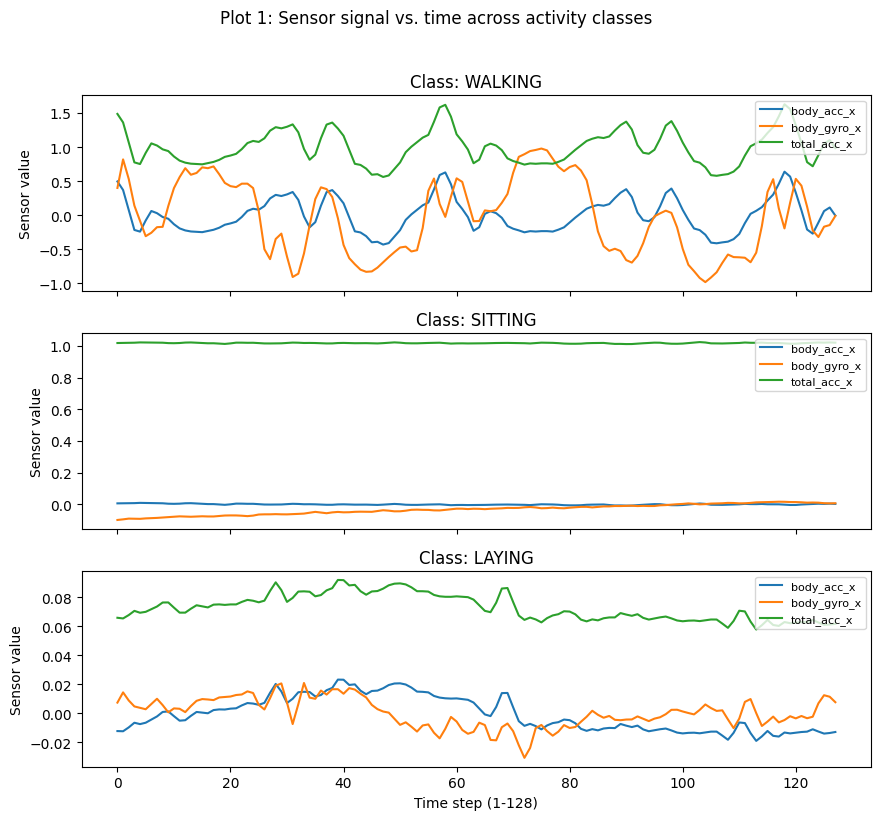

In [5]:

fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
example_classes = [0, 3, 5]  # WALKING, SITTING, LAYING
channels_to_plot = [0, 3, 6]  # body_acc_x, body_gyro_x, total_acc_x
channel_labels = ["body_acc_x", "body_gyro_x", "total_acc_x"]

for ax, cls in zip(axes, example_classes):
    idx = np.where(y_train == cls)[0][0]
    seq = X_train[idx]
    for ch, lbl in zip(channels_to_plot, channel_labels):
        ax.plot(np.arange(SEQ_LEN), seq[:, ch], label=lbl)
    ax.set_title(f"Class: {CLASS_NAMES[cls]}")
    ax.set_ylabel("Sensor value")
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Time step (1-128)")
fig.suptitle("Plot 1: Sensor signal vs. time across activity classes", y=1.02)
fig.tight_layout()
savefig(fig, "plot1_temporal_signals.png")


## 8. Backpropagation Through Time — Numerical Exercise

Manually reproduce $h_1, h_2, h_3$ for the given toy values and compare with a
program.

In [6]:

def rnn_step(x, h_prev, Wx, Wh, b):
    return np.tanh(Wx * x + Wh * h_prev + b)

x_vals = [0.5, 0.7, 0.2]
h = 0.0
Wx, Wh, b = 0.5, 0.8, 0.1

print("Manual BPTT numerical exercise")
for t, x in enumerate(x_vals, start=1):
    h = rnn_step(x, h, Wx, Wh, b)
    print(f"h{t} = {h:.6f}")


Manual BPTT numerical exercise
h1 = 0.336376
h2 = 0.616352
h3 = 0.599958


## 9–12. RNN / LSTM / GRU architectures and training

Identical architecture for all three: `Input(128,9) -> Recurrent(32) -> Dropout(0.2)
-> Dense(16, relu) -> Dense(6, softmax)`, Adam (lr=1e-3), batch size 32, 30 epochs,
sparse categorical cross-entropy. Only the recurrent layer type changes.

In [7]:

def build_model(cell_type, seq_len=SEQ_LEN, n_feat=N_FEAT, n_classes=N_CLASSES, units=32):
    recurrent_layer = {
        "RNN":  layers.SimpleRNN,
        "LSTM": layers.LSTM,
        "GRU":  layers.GRU,
    }[cell_type]

    model = models.Sequential([
        layers.Input(shape=(seq_len, n_feat)),
        recurrent_layer(units, name=f"{cell_type}_layer"),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ], name=f"{cell_type}_classifier")

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

build_model("LSTM").summary()


I0000 00:00:1790142020.781485      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790142020.784564      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "LSTM_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_layer (LSTM)               │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,006 (23.46 KB)

 Trainable params: 6,006 (23.46 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:

# ---- Train RNN, LSTM, GRU under identical conditions -------------------------
EPOCHS = 30
BATCH_SIZE = 32

histories = {}
trained_models = {}
train_times = {}
param_counts = {}

for cell_type in ["RNN", "LSTM", "GRU"]:
    print(f"\n===== Training {cell_type} =====")
    tf.random.set_seed(SEED)
    model = build_model(cell_type)
    t0 = time.time()
    hist = model.fit(
        X_train_n, y_train,
        validation_data=(X_val_n, y_val),
        epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0,
    )
    elapsed = time.time() - t0

    histories[cell_type] = hist
    trained_models[cell_type] = model
    train_times[cell_type] = elapsed
    param_counts[cell_type] = model.count_params()
    print(f"{cell_type}: trained in {elapsed:.1f}s, "
          f"{param_counts[cell_type]} params, "
          f"final val_acc={hist.history['val_accuracy'][-1]:.4f}")



===== Training RNN =====


I0000 00:00:1790142026.355529     133 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


RNN: trained in 24.7s, 1974 params, final val_acc=0.7111

===== Training LSTM =====
LSTM: trained in 22.0s, 6006 params, final val_acc=0.9278

===== Training GRU =====
GRU: trained in 19.1s, 4758 params, final val_acc=0.9250


## 13. Required Training Plots — Plot 2 (loss) & Plot 3 (accuracy), per model

Saved: /kaggle/working/figures/plot2_rnn_loss.png


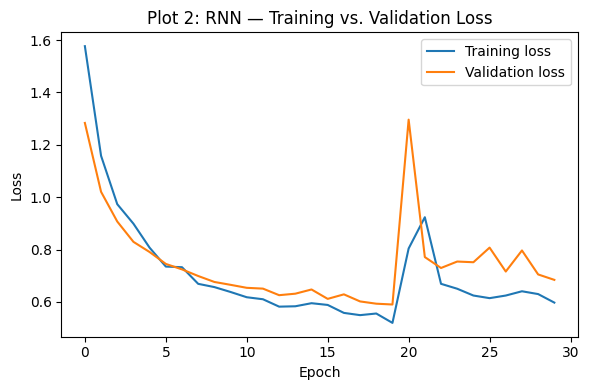

Saved: /kaggle/working/figures/plot3_rnn_accuracy.png


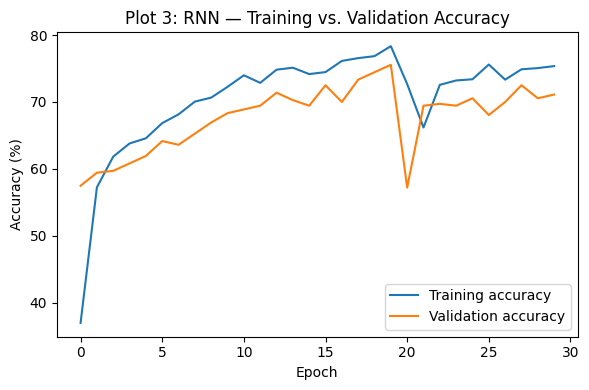

Saved: /kaggle/working/figures/plot2_lstm_loss.png


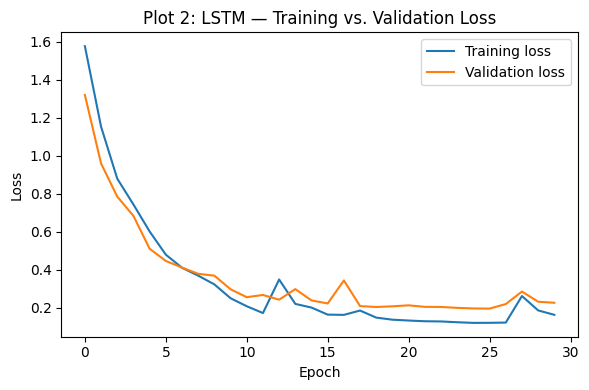

Saved: /kaggle/working/figures/plot3_lstm_accuracy.png


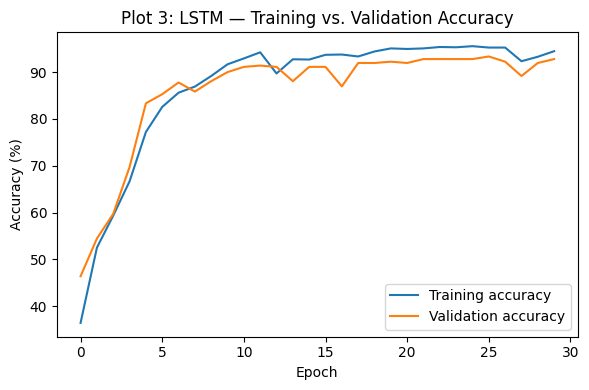

Saved: /kaggle/working/figures/plot2_gru_loss.png


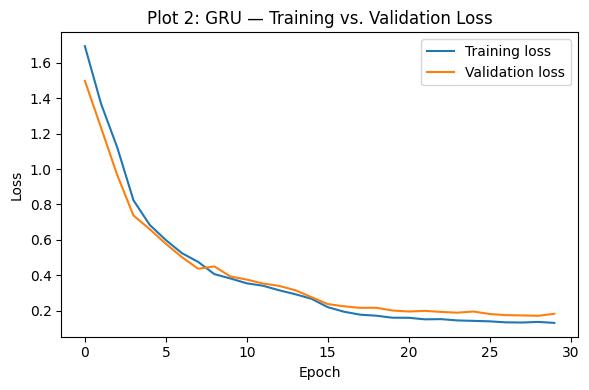

Saved: /kaggle/working/figures/plot3_gru_accuracy.png


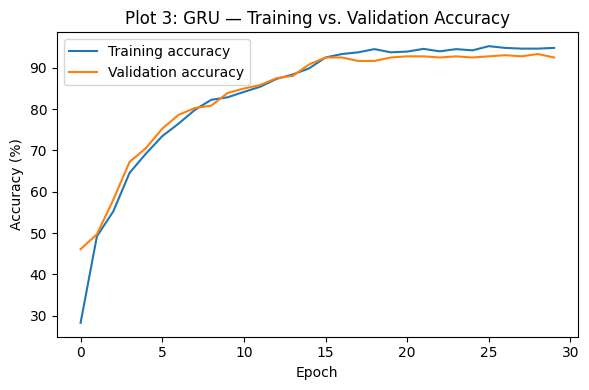

In [9]:

for cell_type, hist in histories.items():
    h = hist.history

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(h["loss"], label="Training loss")
    ax.plot(h["val_loss"], label="Validation loss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title(f"Plot 2: {cell_type} — Training vs. Validation Loss")
    ax.legend()
    fig.tight_layout()
    savefig(fig, f"plot2_{cell_type.lower()}_loss.png")

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(np.array(h["accuracy"]) * 100, label="Training accuracy")
    ax.plot(np.array(h["val_accuracy"]) * 100, label="Validation accuracy")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.set_title(f"Plot 3: {cell_type} — Training vs. Validation Accuracy")
    ax.legend()
    fig.tight_layout()
    savefig(fig, f"plot3_{cell_type.lower()}_accuracy.png")


## 14–15. Performance Evaluation and Confusion Matrices (Plot 4)

Saved: /kaggle/working/figures/plot4_rnn_confusion_matrix.png


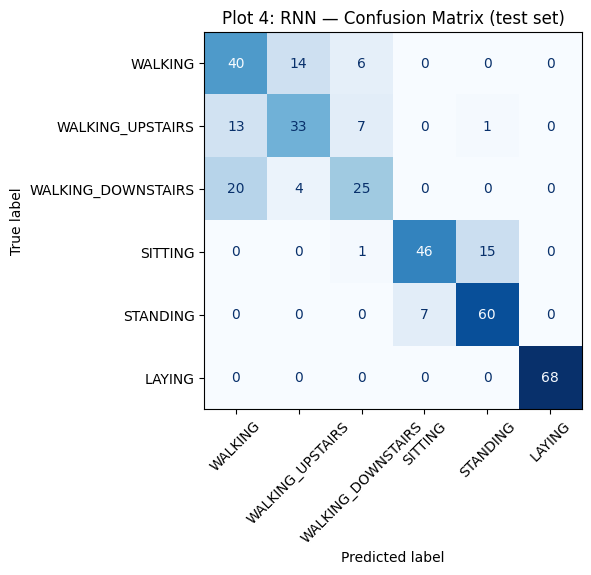

Saved: /kaggle/working/figures/plot4_lstm_confusion_matrix.png


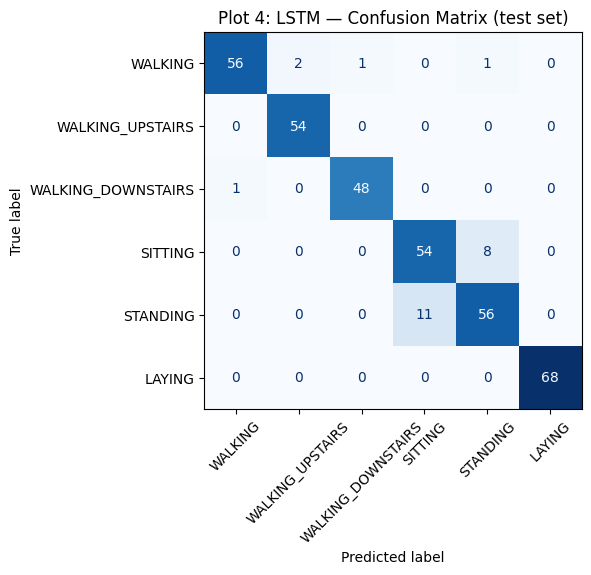

Saved: /kaggle/working/figures/plot4_gru_confusion_matrix.png


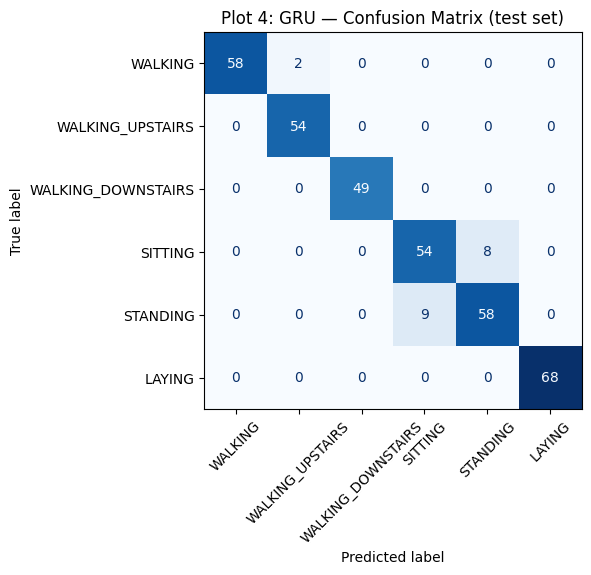

Saved: /kaggle/working/tables/table_performance_evaluation.csv


,Model,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
0,RNN,75.56,74.89,73.76,73.96,1974,24.69
1,LSTM,93.33,93.64,93.66,93.63,6006,22.01
2,GRU,94.72,95.00,95.06,95.02,4758,19.08


In [10]:

results = []
for cell_type, model in trained_models.items():
    y_pred = np.argmax(model.predict(X_test_n, verbose=0), axis=1)

    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )

    results.append({
        "Model": cell_type,
        "Accuracy (%)": round(acc * 100, 2),
        "Macro Precision (%)": round(prec * 100, 2),
        "Macro Recall (%)": round(rec * 100, 2),
        "Macro F1 (%)": round(f1 * 100, 2),
        "Parameters": param_counts[cell_type],
        "Training Time (s)": round(train_times[cell_type], 2),
    })

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
    ax.set_title(f"Plot 4: {cell_type} — Confusion Matrix (test set)")
    fig.tight_layout()
    savefig(fig, f"plot4_{cell_type.lower()}_confusion_matrix.png")

results_df = pd.DataFrame(results)
savetab(results_df, "table_performance_evaluation.csv")
results_df


## 16. RNN vs. LSTM vs. GRU Comparison Table

In [11]:

gate_table = pd.DataFrame({
    "Property": ["Hidden state", "Cell state", "Forget gate", "Input gate",
                 "Output gate", "Update gate", "Reset gate",
                 "Parameters", "Training time (s)", "Test F1-score (%)"],
    "RNN":  ["Yes", "No", "No", "No", "No", "No", "No",
             param_counts["RNN"], round(train_times["RNN"], 2),
             results_df.loc[results_df.Model == "RNN", "Macro F1 (%)"].values[0]],
    "LSTM": ["Yes", "Yes", "Yes", "Yes", "Yes", "No", "No",
             param_counts["LSTM"], round(train_times["LSTM"], 2),
             results_df.loc[results_df.Model == "LSTM", "Macro F1 (%)"].values[0]],
    "GRU":  ["Yes", "No", "No", "No", "No", "Yes", "Yes",
             param_counts["GRU"], round(train_times["GRU"], 2),
             results_df.loc[results_df.Model == "GRU", "Macro F1 (%)"].values[0]],
})
savetab(gate_table, "table_rnn_lstm_gru_comparison.csv")
gate_table


Saved: /kaggle/working/tables/table_rnn_lstm_gru_comparison.csv


,Property,RNN,LSTM,GRU
0,Hidden state,Yes,Yes,Yes
1,Cell state,No,Yes,No
2,Forget gate,No,Yes,No
3,Input gate,No,Yes,No
4,Output gate,No,Yes,No
5,Update gate,No,No,Yes
6,Reset gate,No,No,Yes
7,Parameters,1974,6006,4758
8,Training time (s),24.69,22.01,19.08
9,Test F1-score (%),73.96,93.63,95.02


Saved: /kaggle/working/figures/plot5_model_comparison.png


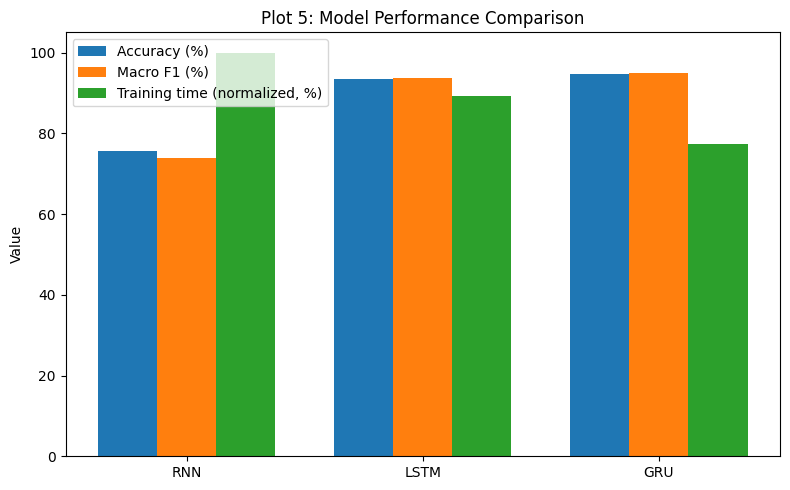

In [12]:

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(results_df))
width = 0.25

ax.bar(x - width, results_df["Accuracy (%)"], width, label="Accuracy (%)")
ax.bar(x,          results_df["Macro F1 (%)"], width, label="Macro F1 (%)")
norm_time = results_df["Training Time (s)"] / results_df["Training Time (s)"].max() * 100
ax.bar(x + width,  norm_time, width, label="Training time (normalized, %)")

ax.set_xticks(x); ax.set_xticklabels(results_df["Model"])
ax.set_ylabel("Value")
ax.set_title("Plot 5: Model Performance Comparison")
ax.legend()
fig.tight_layout()
savefig(fig, "plot5_model_comparison.png")


**Required inference:** discuss the trade-off between predictive performance,
model complexity (parameter count) and training cost, referencing the numbers in
the tables above.

## 17. Effect of Sequence Length 



In [13]:

EPOCHS_SEQLEN = 15
SEQ_LENGTHS = [32, 64, 128]

seqlen_results = []
early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=4,
                                      restore_best_weights=True)

for T in SEQ_LENGTHS:
    Xtr_T = X_train_n[:, :T, :]
    Xva_T = X_val_n[:, :T, :]
    Xte_T = X_test_n[:, :T, :]

    for cell_type in ["RNN", "LSTM", "GRU"]:
        tf.random.set_seed(SEED)
        model = build_model(cell_type, seq_len=T)
        model.fit(Xtr_T, y_train, validation_data=(Xva_T, y_val),
                  epochs=EPOCHS_SEQLEN, batch_size=BATCH_SIZE,
                  callbacks=[early_stop], verbose=0)
        y_pred = np.argmax(model.predict(Xte_T, verbose=0), axis=1)
        _, _, f1, _ = precision_recall_fscore_support(
            y_test, y_pred, average="macro", zero_division=0
        )
        seqlen_results.append({"Sequence Length": T, "Model": cell_type,
                                "F1 (%)": round(f1 * 100, 2)})
        print(f"T={T:3d}  {cell_type:5s}  F1={f1*100:.2f}%")

seqlen_df = pd.DataFrame(seqlen_results)
seqlen_pivot = seqlen_df.pivot(index="Sequence Length", columns="Model", values="F1 (%)")
savetab(seqlen_pivot.reset_index(), "table_sequence_length_f1.csv")
seqlen_pivot


T= 32  RNN    F1=69.04%
T= 32  LSTM   F1=92.64%
T= 32  GRU    F1=35.24%
T= 64  RNN    F1=32.16%
T= 64  LSTM   F1=38.44%
T= 64  GRU    F1=51.93%
T=128  RNN    F1=43.26%
T=128  LSTM   F1=38.53%
T=128  GRU    F1=48.43%
Saved: /kaggle/working/tables/table_sequence_length_f1.csv


Model,GRU,LSTM,RNN
Sequence Length,,,
32,35.24,92.64,69.04
64,51.93,38.44,32.16
128,48.43,38.53,43.26


Saved: /kaggle/working/figures/plot6_seqlen_vs_f1.png


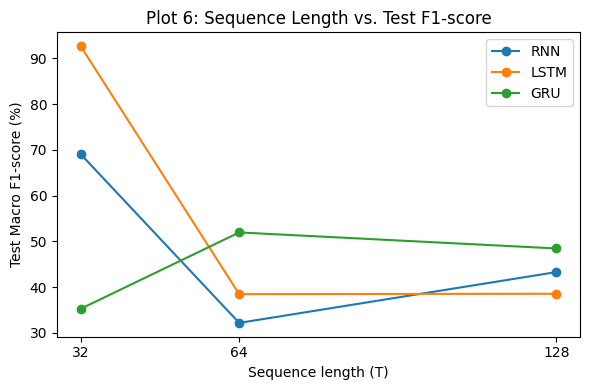

In [14]:

fig, ax = plt.subplots(figsize=(6, 4))
for cell_type in ["RNN", "LSTM", "GRU"]:
    ax.plot(seqlen_pivot.index, seqlen_pivot[cell_type], marker="o", label=cell_type)
ax.set_xlabel("Sequence length (T)")
ax.set_ylabel("Test Macro F1-score (%)")
ax.set_title("Plot 6: Sequence Length vs. Test F1-score")
ax.set_xticks(SEQ_LENGTHS)
ax.legend()
fig.tight_layout()
savefig(fig, "plot6_seqlen_vs_f1.png")


**Required inference:** discuss how more temporal context (larger T) affects
classification quality, and whether LSTM/GRU handle short sequences (T=32) better
than the Vanilla RNN due to their gating mechanisms.

In [15]:

try:
    import cv2
except ImportError:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "opencv-python"])
    import cv2


In [28]:
import re

N_FRAMES = 10
FRAME_SIZE = (224, 224)

VIDEO_DIRS = [
    "/kaggle/input/datasets/abdallahwagih/ucf101-videos/train",
    "/kaggle/input/datasets/abdallahwagih/ucf101-videos/test",
]

def parse_class_from_filename(fname):
    m = re.match(r"v_(.+?)_g\d+_c\d+\.avi", fname)
    return m.group(1) if m else None

def collect_video_paths(video_dirs, classes):
    items = []
    for d in video_dirs:
        if not os.path.isdir(d):
            print(f"Warning: directory not found -> {d}")
            continue
        for fname in sorted(os.listdir(d)):
            if not fname.lower().endswith(".avi"):
                continue
            cls = parse_class_from_filename(fname)
            if cls in classes:
                items.append((os.path.join(d, fname), cls))
    return items

all_classes = set()
for d in VIDEO_DIRS:
    if os.path.isdir(d):
        for fname in os.listdir(d):
            cls = parse_class_from_filename(fname)
            if cls:
                all_classes.add(cls)
print(f"Found {len(all_classes)} distinct classes.")
print("Sample of available classes:", sorted(all_classes)[:20])

SELECTED_CLASSES = ["Punch", "TennisSwing", "Basketball", "Biking", "PushUps"]

video_items = collect_video_paths(VIDEO_DIRS, SELECTED_CLASSES)
print(f"Found {len(video_items)} videos across "
      f"{len(set(c for _, c in video_items))} of your {len(SELECTED_CLASSES)} selected classes.")

Found 5 distinct classes.
Sample of available classes: ['CricketShot', 'PlayingCello', 'Punch', 'ShavingBeard', 'TennisSwing']
Found 326 videos across 2 of your 5 selected classes.


In [30]:
# ---- Sample N_FRAMES uniformly from a video, resized to 224x224x3 -----------
def sample_frames(video_path, n_frames=N_FRAMES, size=FRAME_SIZE):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return None
    idxs = np.linspace(0, max(total - 1, 0), n_frames).astype(int)
    frames = []
    for i in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ok, frame = cap.read()
        if not ok:
            cap.release()
            return None
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, size)
        frames.append(frame)
    cap.release()
    return np.stack(frames, axis=0)

### 20. CNN Feature Extraction (frozen MobileNetV2, no training)

In [31]:

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

cnn_backbone = MobileNetV2(input_shape=(224, 224, 3), include_top=False,
                            pooling="avg", weights="imagenet")
cnn_backbone.trainable = False  # freeze: feature extractor only
FEATURE_DIM = cnn_backbone.output_shape[-1]
print("CNN feature dimension D =", FEATURE_DIM)

def extract_video_features(video_items, batch_size=8):
    X_feats, y_labels, kept_paths = [], [], []
    for path, cls in video_items:
        frames = sample_frames(path)
        if frames is None:
            continue
        frames_pp = preprocess_input(frames.astype(np.float32))
        feats = cnn_backbone.predict(frames_pp, verbose=0)   # (N_FRAMES, D)
        X_feats.append(feats)
        y_labels.append(cls)
        kept_paths.append(path)
    if not X_feats:
        return None, None, None
    return np.stack(X_feats, axis=0), np.array(y_labels), kept_paths

if video_items:
    X_vid_feats, y_vid_labels, vid_paths = extract_video_features(video_items)
    print("Feature tensor shape supplied to the recurrent network:", X_vid_feats.shape)
    # -> (B, 10, D) as required by the handout
else:
    print("No videos found yet — populate VIDEO_ROOT as described above, "
          "then re-run this cell.")


CNN feature dimension D = 1280


2026-09-23 05:45:40.699826: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 05:45:40.856403: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 05:45:40.993037: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Feature tensor shape supplied to the recurrent network: (322, 10, 1280)


### Plot 7 — sample frames from one video

Saved: /kaggle/working/figures/plot7_video_sample_frames.png


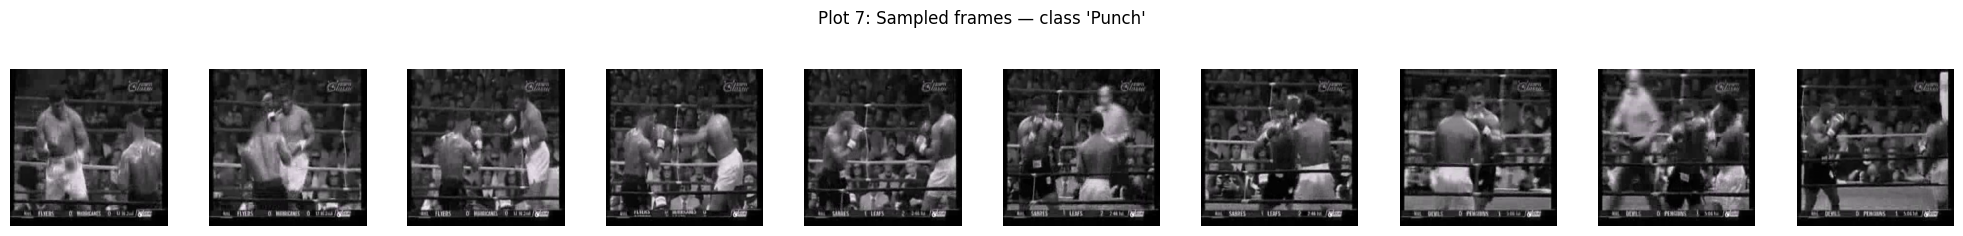

In [32]:

if video_items:
    sample_path, sample_cls = video_items[0]
    frames = sample_frames(sample_path)
    fig, axes = plt.subplots(1, N_FRAMES, figsize=(2 * N_FRAMES, 2.2))
    for ax, frame in zip(axes, frames):
        ax.imshow(frame)
        ax.axis("off")
    fig.suptitle(f"Plot 7: Sampled frames — class '{sample_cls}'", y=1.05)
    fig.tight_layout()
    savefig(fig, "plot7_video_sample_frames.png")


### 21. CNN–LSTM / CNN–GRU classifier

`10 frames -> CNN features (10 x D) -> LSTM/GRU(32) -> Dense -> Softmax`

In [33]:

def build_video_model(cell_type, n_frames=N_FRAMES, feat_dim=FEATURE_DIM, n_classes=None, units=32):
    recurrent_layer = {"LSTM": layers.LSTM, "GRU": layers.GRU}[cell_type]
    model = models.Sequential([
        layers.Input(shape=(n_frames, feat_dim)),
        recurrent_layer(units, name=f"{cell_type}_layer"),
        layers.Dropout(0.3),
        layers.Dense(n_classes, activation="softmax"),
    ], name=f"video_{cell_type}_classifier")
    model.compile(optimizer=optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

if video_items and len(set(y_vid_labels)) > 1:
    vid_class_names = sorted(set(y_vid_labels))
    vid_label_to_idx = {c: i for i, c in enumerate(vid_class_names)}
    y_vid_idx = np.array([vid_label_to_idx[c] for c in y_vid_labels])

    import re
    def extract_group(path):
        fname = os.path.basename(path)
        m = re.search(r"_g(\d+)_", fname)
        return m.group(1) if m else fname

    groups = np.array([extract_group(p) for p in vid_paths])
    unique_groups = np.unique(groups)
    rng = np.random.default_rng(SEED)
    rng.shuffle(unique_groups)

    n_train_g = int(0.6 * len(unique_groups))
    n_val_g = int(0.2 * len(unique_groups))
    train_groups = set(unique_groups[:n_train_g])
    val_groups = set(unique_groups[n_train_g:n_train_g + n_val_g])
    test_groups = set(unique_groups[n_train_g + n_val_g:])

    train_mask = np.array([g in train_groups for g in groups])
    val_mask   = np.array([g in val_groups for g in groups])
    test_mask  = np.array([g in test_groups for g in groups])

    Xv_tr, yv_tr = X_vid_feats[train_mask], y_vid_idx[train_mask]
    Xv_va, yv_va = X_vid_feats[val_mask], y_vid_idx[val_mask]
    Xv_te, yv_te = X_vid_feats[test_mask], y_vid_idx[test_mask]

    print("train/val/test sizes:", train_mask.sum(), val_mask.sum(), test_mask.sum())

    video_histories = {}
    video_models = {}
    for cell_type in ["LSTM", "GRU"]:
        model = build_video_model(cell_type, n_classes=len(vid_class_names))
        hist = model.fit(Xv_tr, yv_tr, validation_data=(Xv_va, yv_va),
                          epochs=20, batch_size=4, verbose=0)
        video_histories[cell_type] = hist
        video_models[cell_type] = model
        print(f"video-{cell_type}: final val_acc={hist.history['val_accuracy'][-1]:.3f}")
else:
    print("Skipping video model training: need >=2 videos across >=2 classes. "
          "Populate VIDEO_ROOT with a few videos per class and re-run from Section 18.")


train/val/test sizes: 193 64 65
video-LSTM: final val_acc=1.000
video-GRU: final val_acc=1.000


### Plot 8 — video training/validation curves, Plot 9 — video confusion matrix

Saved: /kaggle/working/figures/plot8_video_lstm_curves.png


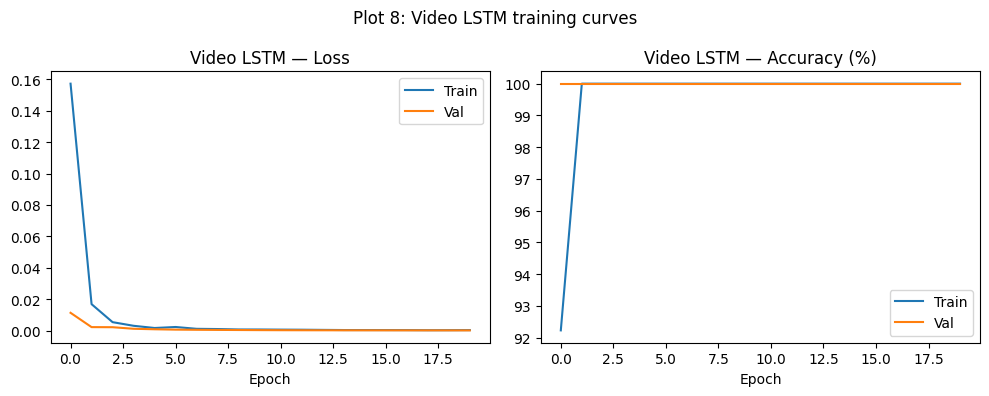

Saved: /kaggle/working/figures/plot9_video_lstm_confusion_matrix.png


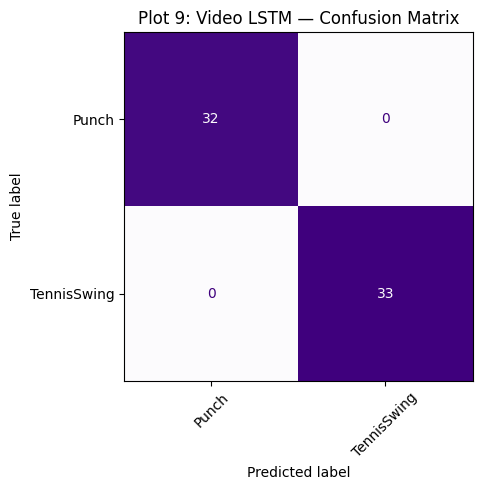

Saved: /kaggle/working/figures/plot8_video_gru_curves.png


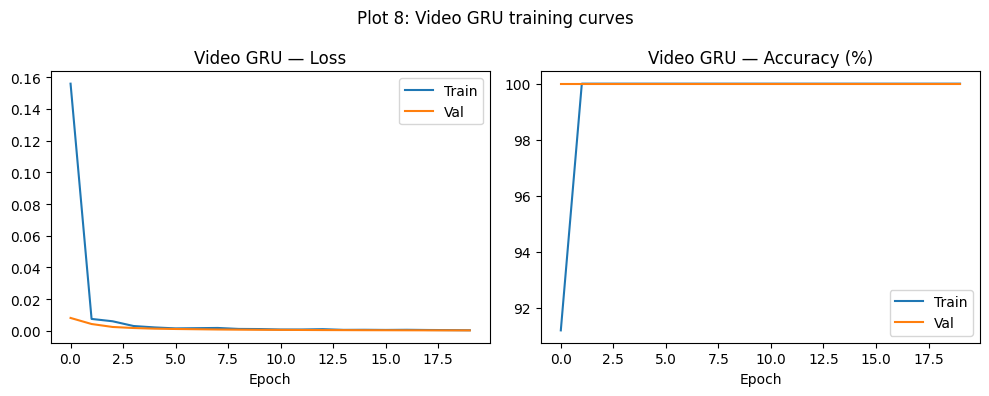

Saved: /kaggle/working/figures/plot9_video_gru_confusion_matrix.png


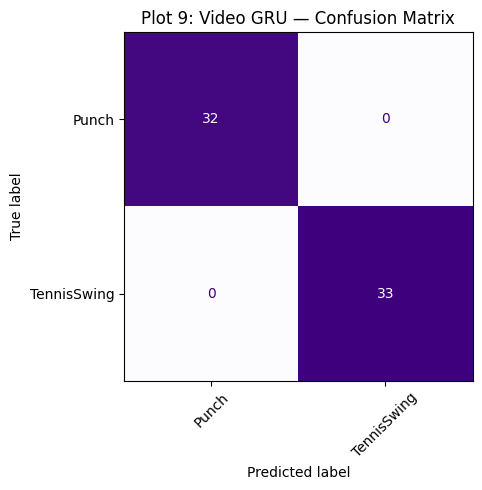

In [35]:

if video_items and len(set(y_vid_labels)) > 1:
    for cell_type, hist in video_histories.items():
        h = hist.history
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].plot(h["loss"], label="Train"); axes[0].plot(h["val_loss"], label="Val")
        axes[0].set_title(f"Video {cell_type} — Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
        axes[1].plot(np.array(h["accuracy"])*100, label="Train")
        axes[1].plot(np.array(h["val_accuracy"])*100, label="Val")
        axes[1].set_title(f"Video {cell_type} — Accuracy (%)"); axes[1].set_xlabel("Epoch"); axes[1].legend()
        fig.suptitle(f"Plot 8: Video {cell_type} training curves")
        fig.tight_layout()
        savefig(fig, f"plot8_video_{cell_type.lower()}_curves.png")

        y_pred = np.argmax(video_models[cell_type].predict(Xv_te, verbose=0), axis=1)
        cm = confusion_matrix(yv_te, y_pred, labels=list(range(len(vid_class_names))))
        fig, ax = plt.subplots(figsize=(5, 5))
        ConfusionMatrixDisplay(cm, display_labels=vid_class_names).plot(
            ax=ax, cmap="Purples", xticks_rotation=45, colorbar=False)
        ax.set_title(f"Plot 9: Video {cell_type} — Confusion Matrix")
        fig.tight_layout()
        savefig(fig, f"plot9_video_{cell_type.lower()}_confusion_matrix.png")


## 22–24. Sequence-to-Sequence Learning (synthetic reversal task)

Encoder-decoder LSTM trained with teacher forcing on `[a,b,c,d] -> [d,c,b,a]`.

In [36]:

# ---- Build the synthetic reversal dataset ------------------------------------
VOCAB_MIN, VOCAB_MAX = 0, 9          # integers 0-9
SEQ2SEQ_LEN = 4
N_SAMPLES = 8000
PAD_TOKEN = 10                        # padding / start token index
VOCAB_SIZE = VOCAB_MAX + 2            # 0-9 digits + PAD/START

rng = np.random.default_rng(SEED)
src_sequences = rng.integers(VOCAB_MIN, VOCAB_MAX + 1, size=(N_SAMPLES, SEQ2SEQ_LEN))
tgt_sequences = src_sequences[:, ::-1]

# decoder input = <START> + target[:-1]  (teacher forcing)
decoder_input = np.concatenate(
    [np.full((N_SAMPLES, 1), PAD_TOKEN), tgt_sequences[:, :-1]], axis=1
)

Xs_tr, Xs_tmp, Xd_tr, Xd_tmp, ys_tr, ys_tmp = train_test_split(
    src_sequences, decoder_input, tgt_sequences, test_size=0.3, random_state=SEED
)
Xs_va, Xs_te, Xd_va, Xd_te, ys_va, ys_te = train_test_split(
    Xs_tmp, Xd_tmp, ys_tmp, test_size=0.5, random_state=SEED
)
print("Train/val/test sizes:", len(Xs_tr), len(Xs_va), len(Xs_te))


Train/val/test sizes: 5600 1200 1200


In [37]:

# ---- Encoder-decoder LSTM model ----------------------------------------------
EMBED_DIM, HIDDEN_UNITS = 32, 64

# Encoder
enc_inputs = layers.Input(shape=(SEQ2SEQ_LEN,), name="encoder_input")
enc_embedding_layer = layers.Embedding(VOCAB_SIZE, EMBED_DIM, name="encoder_embedding")
enc_emb = enc_embedding_layer(enc_inputs)
_, state_h, state_c = layers.LSTM(HIDDEN_UNITS, return_state=True)(enc_emb)

# Decoder (teacher forcing during training)
dec_inputs = layers.Input(shape=(SEQ2SEQ_LEN,), name="decoder_input")
dec_embedding_layer = layers.Embedding(VOCAB_SIZE, EMBED_DIM, name="decoder_embedding")
dec_emb = dec_embedding_layer(dec_inputs)
dec_lstm = layers.LSTM(HIDDEN_UNITS, return_sequences=True, return_state=True)
dec_outputs, _, _ = dec_lstm(dec_emb, initial_state=[state_h, state_c])
dec_dense = layers.Dense(VOCAB_SIZE, activation="softmax")
dec_outputs = dec_dense(dec_outputs)

seq2seq_model = models.Model([enc_inputs, dec_inputs], dec_outputs, name="seq2seq_reversal")
seq2seq_model.compile(optimizer=optimizers.Adam(1e-3),
                       loss="sparse_categorical_crossentropy", metrics=["accuracy"])
seq2seq_model.summary()


Model: "seq2seq_reversal"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 4, 32)     │        352 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 4, 32)     │        352 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 64),      │     24,832 │ encoder_embeddin… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, 4, 64),   │     24,832 │ decoder_embeddin… │
│                     │ (None, 64),       │            │ lstm_2[0][1],     │
│                     │ (None, 64)]       │            │ lstm_2[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 4, 11)     │        715 │ lstm_3[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 51,083 (199.54 KB)

 Trainable params: 51,083 (199.54 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:

seq2seq_hist = seq2seq_model.fit(
    [Xs_tr, Xd_tr], ys_tr,
    validation_data=([Xs_va, Xd_va], ys_va),
    epochs=30, batch_size=64, verbose=0,
)
print("Final train loss:", seq2seq_hist.history["loss"][-1],
      "| Final val loss:", seq2seq_hist.history["val_loss"][-1])


Final train loss: 0.0011940051335841417 | Final val loss: 0.0013945818645879626


In [40]:

# ---- Standalone encoder / decoder for inference (no teacher forcing) --------
encoder_model = models.Model(enc_inputs, [state_h, state_c])

dec_state_h_in = layers.Input(shape=(HIDDEN_UNITS,))
dec_state_c_in = layers.Input(shape=(HIDDEN_UNITS,))
dec_single_in = layers.Input(shape=(1,))
dec_single_emb = dec_embedding_layer(dec_single_in)
dec_single_out, dec_h, dec_c = dec_lstm(dec_single_emb, initial_state=[dec_state_h_in, dec_state_c_in])
dec_single_pred = dec_dense(dec_single_out)
decoder_step_model = models.Model(
    [dec_single_in, dec_state_h_in, dec_state_c_in],
    [dec_single_pred, dec_h, dec_c],
)

def predict_sequence(src_seq):
    h, c = encoder_model.predict(src_seq[None, :], verbose=0)
    tok = np.array([[PAD_TOKEN]])
    output = []
    for _ in range(SEQ2SEQ_LEN):
        pred, h, c = decoder_step_model.predict([tok, h, c], verbose=0)
        next_tok = int(np.argmax(pred[0, 0]))
        output.append(next_tok)
        tok = np.array([[next_tok]])
    return np.array(output)


In [41]:

# ---- 23. Show at least 5 test examples --------------------------------------
example_rows = []
for i in range(5):
    src = Xs_te[i]
    pred = predict_sequence(src)
    example_rows.append({
        "Sample": i + 1,
        "Input Sequence": list(src),
        "Predicted Output": list(pred),
        "Expected Output": list(ys_te[i]),
    })
examples_df = pd.DataFrame(example_rows)
savetab(examples_df, "table_seq2seq_examples.csv")
examples_df


Saved: /kaggle/working/tables/table_seq2seq_examples.csv


,Sample,Input Sequence,Predicted Output,Expected Output
0,1,"[8, 1, 6, 5]","[5, 6, 1, 8]","[5, 6, 1, 8]"
1,2,"[8, 6, 1, 2]","[2, 1, 6, 8]","[2, 1, 6, 8]"
2,3,"[6, 1, 4, 1]","[1, 4, 1, 6]","[1, 4, 1, 6]"
3,4,"[9, 6, 1, 2]","[2, 1, 6, 9]","[2, 1, 6, 9]"
4,5,"[4, 5, 2, 8]","[8, 2, 5, 4]","[8, 2, 5, 4]"


In [42]:

# ---- 24. Token accuracy & sequence accuracy on the full test set ------------
all_preds = np.stack([predict_sequence(s) for s in Xs_te], axis=0)

token_acc = (all_preds == ys_te).mean()
sequence_acc = (all_preds == ys_te).all(axis=1).mean()

seq2seq_metrics = pd.DataFrame([{
    "Token Accuracy": round(token_acc, 4),
    "Sequence Accuracy": round(sequence_acc, 4),
    "Final Training Loss": round(seq2seq_hist.history["loss"][-1], 4),
    "Final Validation Loss": round(seq2seq_hist.history["val_loss"][-1], 4),
}])
savetab(seq2seq_metrics, "table_seq2seq_metrics.csv")
seq2seq_metrics


Saved: /kaggle/working/tables/table_seq2seq_metrics.csv


,Token Accuracy,Sequence Accuracy,Final Training Loss,Final Validation Loss
0,1.0,1.0,0.0012,0.0014


## 25. Consolidated Results

In [43]:

consolidated = results_df[["Model", "Accuracy (%)", "Macro Precision (%)",
                            "Macro Recall (%)", "Macro F1 (%)", "Parameters"]].copy()
consolidated = consolidated.rename(columns={
    "Accuracy (%)": "Accuracy", "Macro Precision (%)": "Precision",
    "Macro Recall (%)": "Recall", "Macro F1 (%)": "F1",
})

if video_items and len(set(y_vid_labels)) > 1:
    for cell_type, model in video_models.items():
        y_pred = np.argmax(model.predict(Xv_te, verbose=0), axis=1)
        acc = accuracy_score(yv_te, y_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(
            yv_te, y_pred, average="macro", zero_division=0)
        consolidated.loc[len(consolidated)] = [
            f"CNN-{cell_type}", round(acc*100, 2), round(prec*100, 2),
            round(rec*100, 2), round(f1*100, 2), model.count_params()]

savetab(consolidated, "table_consolidated_results.csv")
consolidated


Saved: /kaggle/working/tables/table_consolidated_results.csv


,Model,Accuracy,Precision,Recall,F1,Parameters
0,RNN,75.56,74.89,73.76,73.96,1974
1,LSTM,93.33,93.64,93.66,93.63,6006
2,GRU,94.72,95.00,95.06,95.02,4758
3,CNN-LSTM,100.00,100.00,100.00,100.00,168130
4,CNN-GRU,100.00,100.00,100.00,100.00,126210


In [44]:

seq2seq_table = pd.DataFrame([{
    "Task": "Sequence-to-Sequence (reversal)",
    "Token Accuracy": seq2seq_metrics.loc[0, "Token Accuracy"],
    "Sequence Accuracy": seq2seq_metrics.loc[0, "Sequence Accuracy"],
    "Training Loss": seq2seq_metrics.loc[0, "Final Training Loss"],
    "Validation Loss": seq2seq_metrics.loc[0, "Final Validation Loss"],
}])
savetab(seq2seq_table, "table_seq2seq_consolidated.csv")
seq2seq_table


Saved: /kaggle/working/tables/table_seq2seq_consolidated.csv


,Task,Token Accuracy,Sequence Accuracy,Training Loss,Validation Loss
0,Sequence-to-Sequence (reversal),1.0,1.0,0.0012,0.0014


In [45]:

import shutil
zip_path = shutil.make_archive(os.path.join(BASE_DIR, "experiment6_outputs"), "zip", BASE_DIR,
                                base_dir=None)
# Zip just the figures+tables folders for a lighter download:
zip_path = shutil.make_archive(os.path.join(BASE_DIR, "experiment6_outputs"), "zip",
                                root_dir=BASE_DIR, base_dir=".")
print("You can also just zip figures/ and tables/ directly, e.g.:")
print("  shutil.make_archive('figures_tables', 'zip', BASE_DIR)")

# Colab convenience (no-op / harmless on Kaggle):
try:
    from google.colab import files as colab_files
    # colab_files.download(zip_path)  # uncomment to auto-trigger a download
    print("Running on Colab — uncomment the line above to auto-download the zip.")
except ImportError:
    print("Not running on Colab — download files via Kaggle's Output/file browser.")


You can also just zip figures/ and tables/ directly, e.g.:
  shutil.make_archive('figures_tables', 'zip', BASE_DIR)
Running on Colab — uncomment the line above to auto-download the zip.
